# 第 08 章 手工细胞类型注释

## 学习目标

把多个标记基因的证据转化为分层的细胞类型标签。

## 为什么做与怎样做

先核对当前聚类与注释参照的一致性，再使用映射写入粗、细两级标签；对证据不足的群体保留不确定性。

前置章节：07。运行前请完成项目环境准备。


In [1]:
from __future__ import annotations
from pathlib import Path
import os
import sys
ROOT = Path(os.environ.get("SC_COURSE_ROOT", Path.cwd())).resolve()
while not (ROOT / "config/course.json").is_file() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if not (ROOT / "config/course.json").is_file():
    raise RuntimeError("请从课程目录或其 notebooks/exercises 目录运行。")
os.environ["CELLTYPIST_FOLDER"] = str(ROOT / ".runtime/celltypist")
os.environ["MPLCONFIGDIR"] = str(ROOT / ".runtime/matplotlib")
sys.path.insert(0, str(ROOT / "tools"))
from course_runtime import start_chapter, marker_sets, scaled_view
import anndata as ad
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.pyplot import rc_context
from scipy.sparse import csr_matrix
from scipy.stats import median_abs_deviation
ctx = start_chapter("08")
adata = ctx.load_input()
sets = marker_sets(adata)
markers_1, markers_2 = sets["fine"], sets["broad"]
markers = markers_1
leiden_res = "leiden_res_0_50"


第 08 章：手工细胞类型注释
结果目录：results/08_manual_annotation/20260915T074833_dd2e88


读取检查点：results/07_marker_visualization/20260915T074022_5c04b4/checkpoint.h5ad
17,041 个细胞 × 23,427 个基因


## 08.1 类群注释

根据当前点图、UMAP 和表达比例为簇提出粗粒度标签。映射针对已经核对的这次聚类；新的数据和聚类结果需要重新核对。

下面读取已核对的映射，并使用 pandas.map 写入细胞注释。config/annotations.json 同时保存聚类指纹和标签，防止把一套聚类的编号用于另一套结果。

In [2]:
leiden_res = "leiden_res_0_02"
coarse_mapping = ctx.annotation_map(adata, leiden_res, "level1")
print(coarse_mapping)
adata.obs["cell_type_res_0.02_lvl1"] = adata.obs[leiden_res].astype(str).map(coarse_mapping).astype("category")

{'0': 'Immune_mixed', '1': 'Myeloid', '2': 'B_cells', '3': 'Erythroid', '4': 'Erythroid'}


In [3]:
# 功能说明：查看细胞注释表。
# 运行目的：确认一级注释列 `cell_type_res_0.02_lvl1` 是否成功添加。
# 详细代码解析：
# 1. `adata.obs`
#    - 打印概览。

adata.obs

,samples,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_mt,...,log1p_total_counts_hb,pct_counts_hb,n_genes,doublet_score,predicted_doublet,leiden_res_0_02,leiden_res_0_50,leiden_res_1_00,leiden_res_2_00,cell_type_res_0.02_lvl1
AAACCCAAGGATGGCT-1,s1d1,2103,7.651596,8663.0,9.066932,42.721921,59.667552,69.744892,79.348955,460.0,...,2.890372,0.196237,2103,0.036113,False,0,0,0,0,Immune_mixed
AAACCCAAGGCCTAGA-1,s1d1,3916,8.273081,12853.0,9.461411,35.843772,44.262040,52.376877,62.763557,1790.0,...,4.077538,0.451257,3912,0.183381,False,1,3,1,1,Myeloid
AAACCCAAGTGAGTGC-1,s1d1,683,6.527958,1631.0,7.397562,56.284488,62.599632,70.386266,88.779890,581.0,...,2.639057,0.797057,683,0.045320,False,2,4,2,2,B_cells
AAACCCACAAGAGGCT-1,s1d1,4330,8.373554,17345.0,9.761117,27.662150,38.420294,48.901701,62.023638,780.0,...,3.806663,0.253675,4328,0.045320,False,0,5,3,3,Immune_mixed
AAACCCACATCGTGGC-1,s1d1,325,5.786897,555.0,6.320768,49.909910,59.459459,77.477477,100.000000,159.0,...,3.295837,4.684685,323,0.016181,False,0,1,4,4,Immune_mixed
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGAGAGTCTGG-1,s1d3,277,5.627621,615.0,6.423247,63.089431,71.219512,87.479675,100.000000,282.0,...,3.044523,3.252032,277,0.032046,False,0,1,5,8,Immune_mixed
TTTGTTGCAGACAATA-1,s1d3,3797,8.242230,13218.0,9.489410,30.753518,44.628537,53.691935,64.684521,864.0,...,3.761200,0.317749,3795,0.078619,False,1,3,1,1,Myeloid
TTTGTTGCATGTTACG-1,s1d3,3089,8.035926,27280.0,10.213945,64.409824,71.671554,78.317449,85.054985,1025.0,...,9.483872,48.185482,3087,0.033898,False,4,11,14,30,Erythroid
TTTGTTGGTAGTCACT-1,s1d3,379,5.940171,698.0,6.549651,52.865330,60.028653,74.355301,100.000000,143.0,...,3.688879,5.587393,379,0.039080,False,0,1,7,7,Immune_mixed


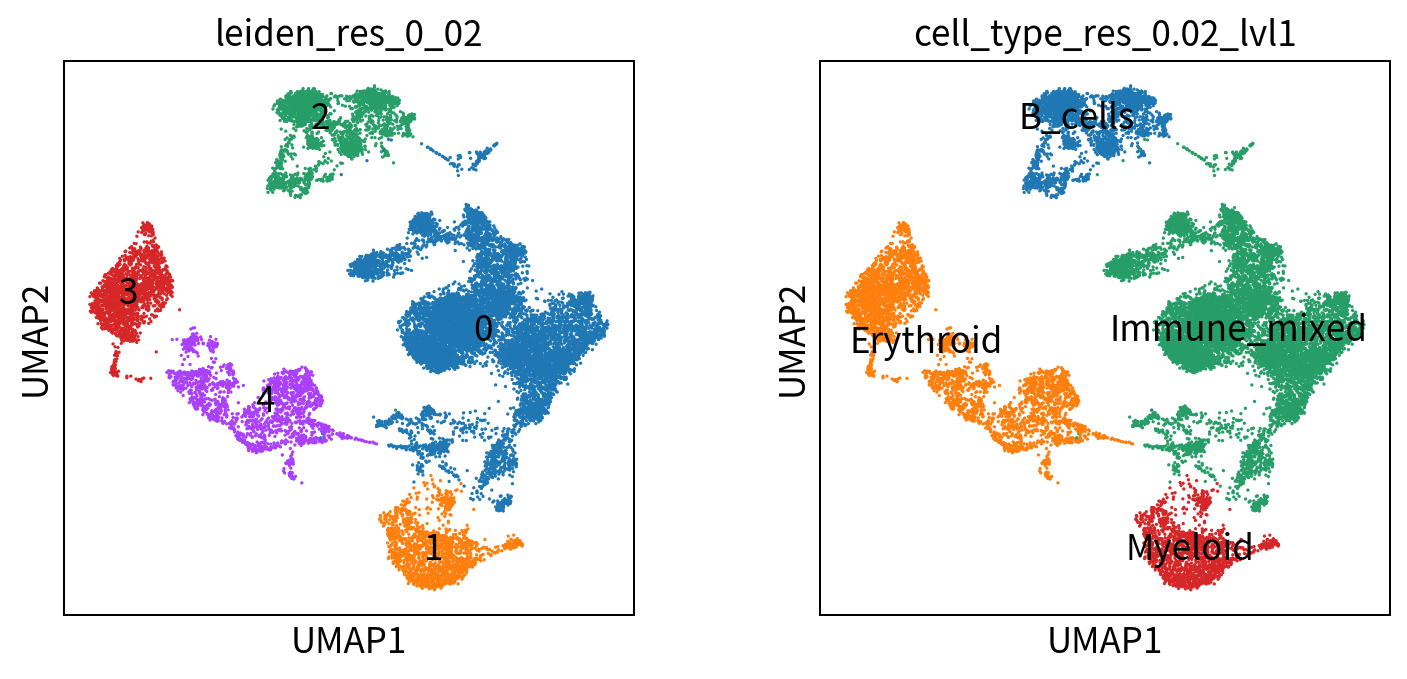

In [4]:
# 功能说明：重复绘制以便在不同分辨率下对比标签布局。
# 运行目的：辅助选择最终用于注释的分辨率。
sc.pl.umap(
    adata,
    color=[leiden_res, "cell_type_res_0.02_lvl1", ],
    legend_loc="on data",
    save="_08_200.pdf",
)


In [5]:
# 功能说明：统计一级注释的细胞数量。
# 运行目的：查看各主要细胞类型的分布情况。
# 详细代码解析：
# 1. `adata.obs["cell_type_res_0.02_lvl1"].value_counts()`
#    - 统计一级注释列中各类别的频数。

# 查看每个类群细胞数量
adata.obs["cell_type_res_0.02_lvl1"].value_counts()

cell_type_res_0.02_lvl1
Immune_mixed    9765
Erythroid       3500
B_cells         2268
Myeloid         1508
Name: count, dtype: int64

## 08.2 更高分辨率下类群注释

In [6]:
# 功能说明：切换到较高分辨率进行细致注释。
# 运行目的：为接下来的二级注释（小类）设置参数，使用分辨率 0.50 和详细标记基因集 `markers_1`。
# 详细代码解析：
# 1. `leiden_res = "leiden_res_0_50"`
#    - 更新分辨率变量。
# 2. `markers = markers_1`
#    - 更新标记基因集变量。

# 定义聚类分辨率变量
leiden_res = "leiden_res_0_50"
# 指定使用的markers版本
markers = markers_1

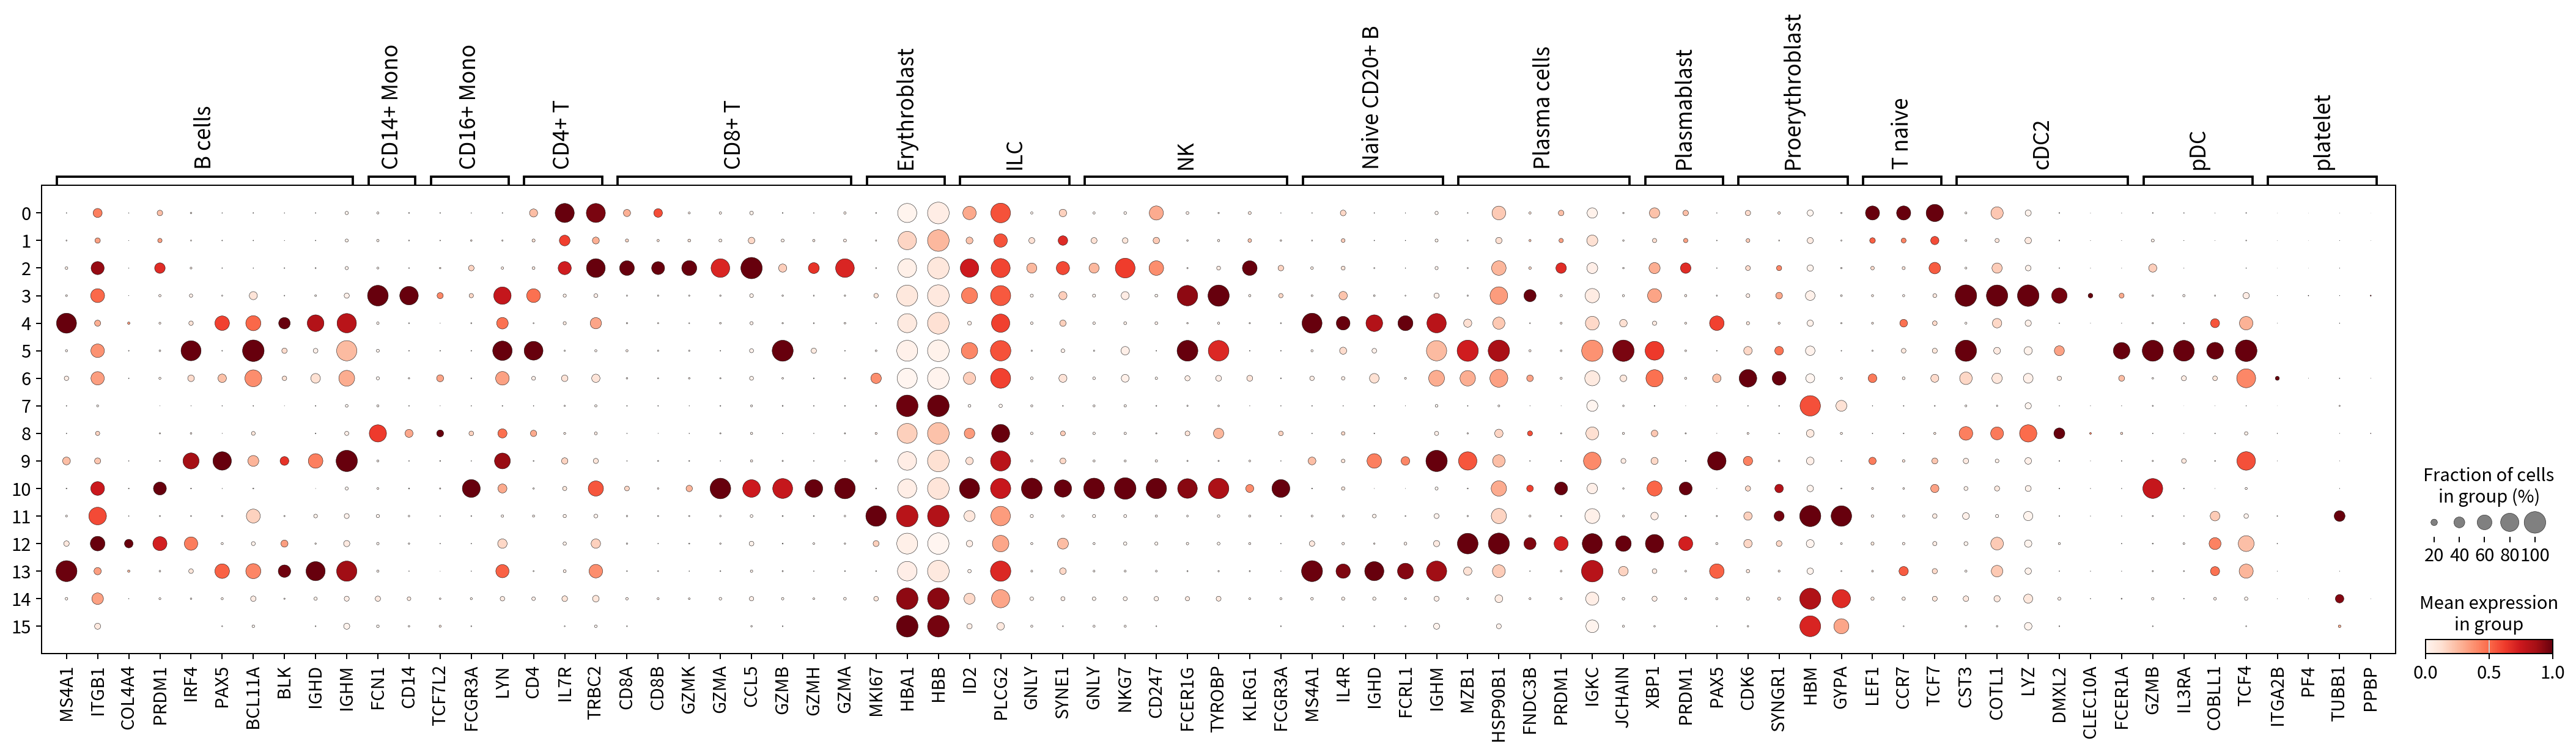

In [7]:
# 功能说明：在较高分辨率簇上查看标记基因表达以细化注释。
# 运行目的：判断更细粒度的细胞类型分群。
sc.pl.dotplot(adata, markers, groupby=leiden_res, standard_scale="var", save="_08_204.pdf")

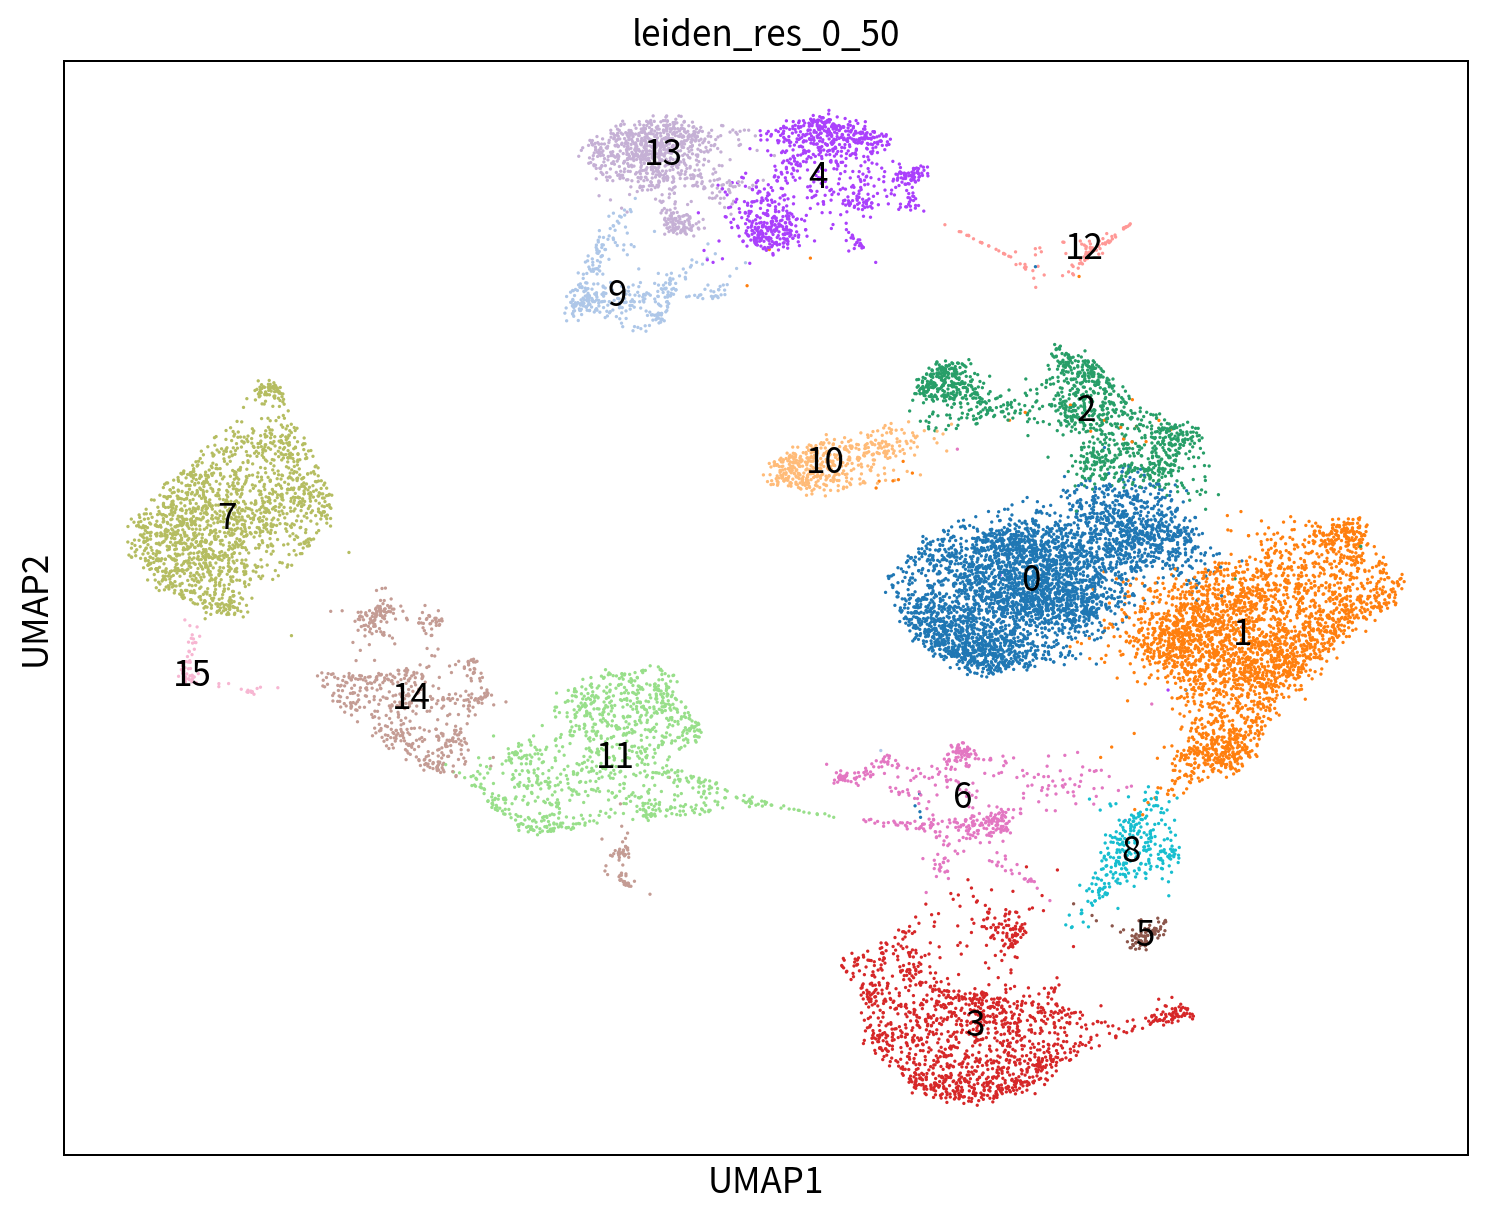

In [8]:
# 功能说明：重复绘制以便在不同分辨率下对比标签布局。
# 运行目的：辅助选择最终用于注释的分辨率。
with rc_context({"figure.figsize": (10, 8)}):
    sc.pl.umap(
        adata,
        color=[leiden_res],
        legend_loc="on data",
    )

In [9]:


# 使用 return_fig 参数返回图形对象
dot_plot = sc.pl.dotplot(
    adata, 
    markers, 
    groupby=leiden_res, 
    standard_scale="var",
    return_fig=True,
    show=False  # 不显示图形，只获取数据
)

# 检查可用的属性
print("可用的属性：", dir(dot_plot))

# 获取点图中的数据
if hasattr(dot_plot, 'dot_color_df'):
    print("颜色数据矩阵（标准化后的表达量）：")
    print(dot_plot.dot_color_df)
    
if hasattr(dot_plot, 'dot_size_df'):
    print("\n点大小数据矩阵（表达比例）：")
    print(dot_plot.dot_size_df)
    
# 最简单的方式：直接获取两个数据框
color_df = dot_plot.dot_color_df
size_df = dot_plot.dot_size_df
# 保存到CSV文件以便进一步分析
ctx.table("dotplot_color_fine", color_df)
ctx.table("dotplot_size_fine", size_df)

可用的属性： ['DEFAULT_CATEGORY_HEIGHT', 'DEFAULT_CATEGORY_WIDTH', 'DEFAULT_COLORMAP', 'DEFAULT_COLOR_LEGEND_TITLE', 'DEFAULT_COLOR_ON', 'DEFAULT_DOT_EDGECOLOR', 'DEFAULT_DOT_EDGELW', 'DEFAULT_DOT_MAX', 'DEFAULT_DOT_MIN', 'DEFAULT_LARGEST_DOT', 'DEFAULT_LEGENDS_WIDTH', 'DEFAULT_PLOT_X_PADDING', 'DEFAULT_PLOT_Y_PADDING', 'DEFAULT_SAVE_PREFIX', 'DEFAULT_SIZE_EXPONENT', 'DEFAULT_SIZE_LEGEND_TITLE', 'DEFAULT_SMALLEST_DOT', 'DEFAULT_WSPACE', 'MAX_NUM_CATEGORIES', 'MIN_FIGURE_HEIGHT', '__annotations__', '__class__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge__', '__getattribute__', '__getstate__', '__gt__', '__hash__', '__init__', '__init_subclass__', '__le__', '__lt__', '__module__', '__ne__', '__new__', '__reduce__', '__reduce_ex__', '__repr__', '__setattr__', '__sizeof__', '__str__', '__subclasshook__', '__weakref__', '_dotplot', '_mainplot', '_plot_colorbar', '_plot_legend', '_plot_size_legend', '_plot_totals', '_reorder_categories_after_dendrogram', 'adata'

PosixPath('/data/home/heqingchuan/workdir/19_方超老师合作_单细胞_gpt6/sc_RNA/sc_RNA_basic_course/results/08_manual_annotation/20260915T074833_dd2e88/tables/dotplot_size_fine.csv')

## 08.3 二级注释的证据组织

先按谱系做一级注释，再在谱系内部判断更细的类型。请同时考虑标记基因的表达比例、平均表达和在其他群体中的分布。单个标记的高表达不足以确认细胞类型。

建议整理包含聚类编号、一级标签、二级标签、支持标记、相反证据及待验证问题的表格。初始 B 细胞、抗体分泌细胞、T/NK 细胞和不同红系状态应分别查看相应的组合标记。对于不能清楚区分的亚型，先使用较宽泛或注明不确定性的标签。

下方展示当前参照映射及注释结果。证据表保存在 config/annotation_evidence.csv，具体参数与运行身份由 annotations.json 关联。

In [10]:
leiden_res = "leiden_res_0_50"
fine_level1 = ctx.annotation_map(adata, leiden_res, "level1")
fine_level2 = ctx.annotation_map(adata, leiden_res, "level2")
print(fine_level2)
adata.obs["cell_type_res_0.50_lvl1"] = adata.obs[leiden_res].astype(str).map(fine_level1).astype("category")
adata.obs["cell_type_res_0.50_lvl2"] = adata.obs[leiden_res].astype(str).map(fine_level2).astype("category")

{'0': 'Naive_memory_T', '1': 'Low_quality_lymphoid_like', '2': 'CD8_cytotoxic_T', '3': 'CD14_Mono', '4': 'Naive_B', '5': 'pDC', '6': 'Progenitor_like', '7': 'Erythroid', '8': 'Myeloid_like_low_quality', '9': 'B_cell', '10': 'NK', '11': 'Cycling_erythroid', '12': 'Antibody_secreting_cell', '13': 'Naive_B', '14': 'Erythroid', '15': 'Erythroid'}


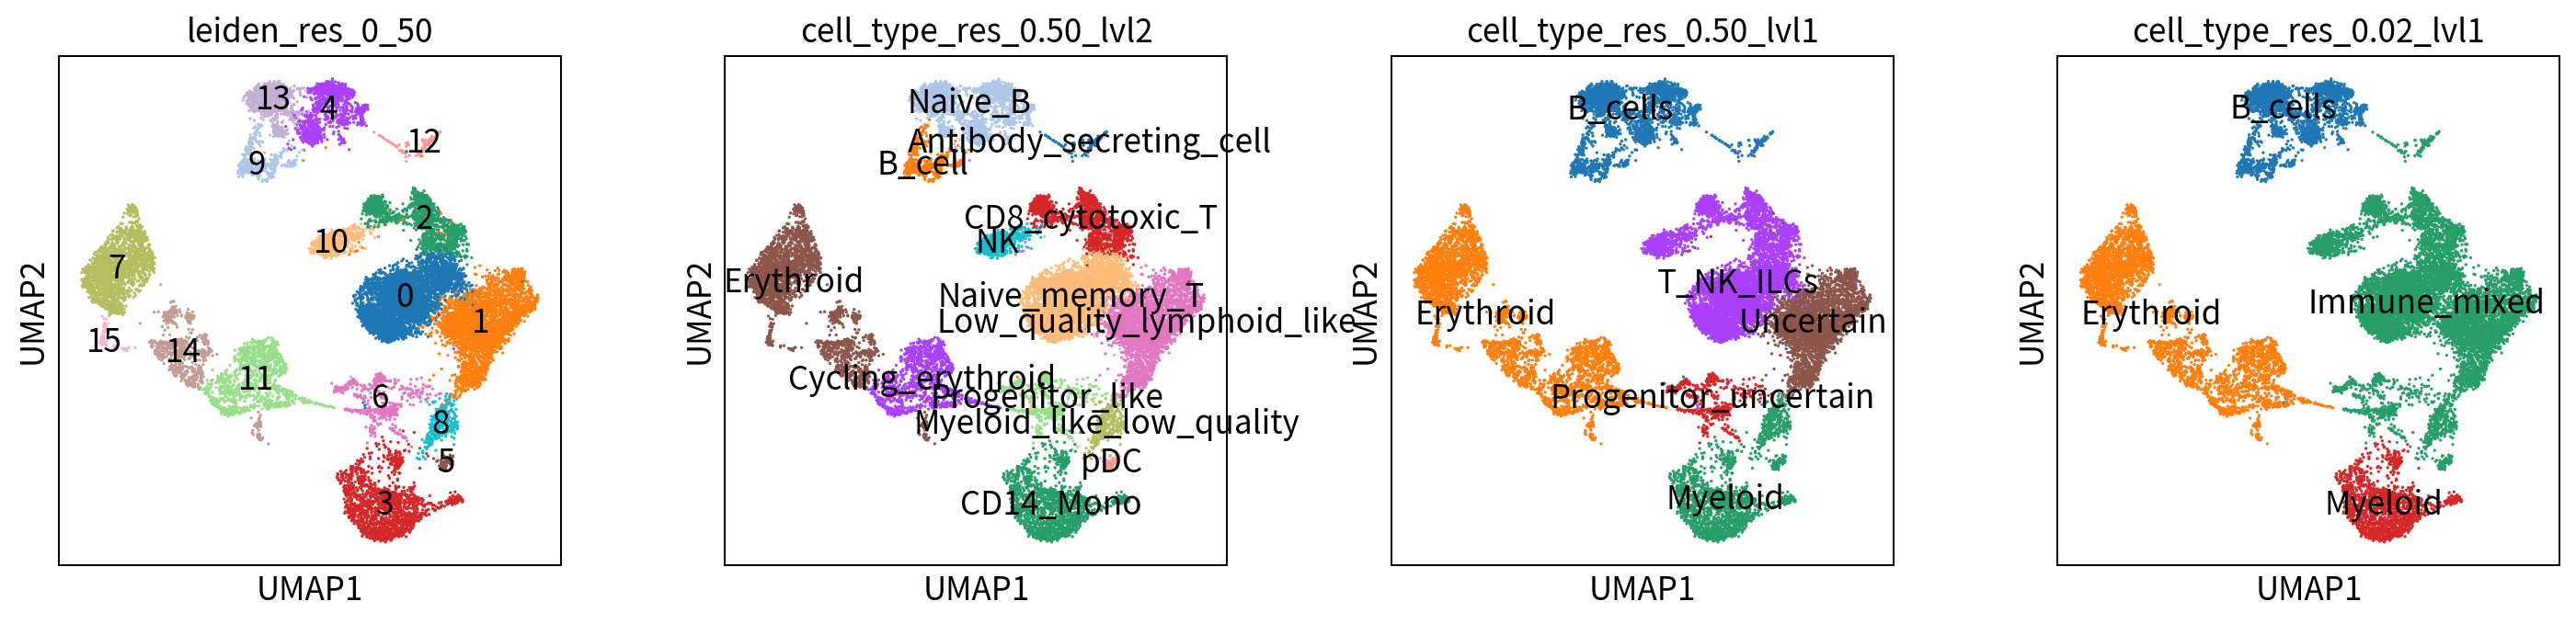

In [11]:
# 功能说明：绘制多面板 UMAP 图，展示聚类和两级注释结果。
# 运行目的：直观对比聚类标签、一级注释和二级注释在空间上的分布。
# 详细代码解析：
# 1. `sc.pl.umap(...)`
#    - `color=[...]`: 同时展示聚类结果、二级注释、一级注释等多个视角。
#    - `save="..."`: 保存图像。

# 查看注释结果

sc.pl.umap(
        adata,
        color=["leiden_res_0_50",  "cell_type_res_0.50_lvl2","cell_type_res_0.50_lvl1", "cell_type_res_0.02_lvl1", ],
        legend_loc="on data",
        save="_08_209.pdf",
        )

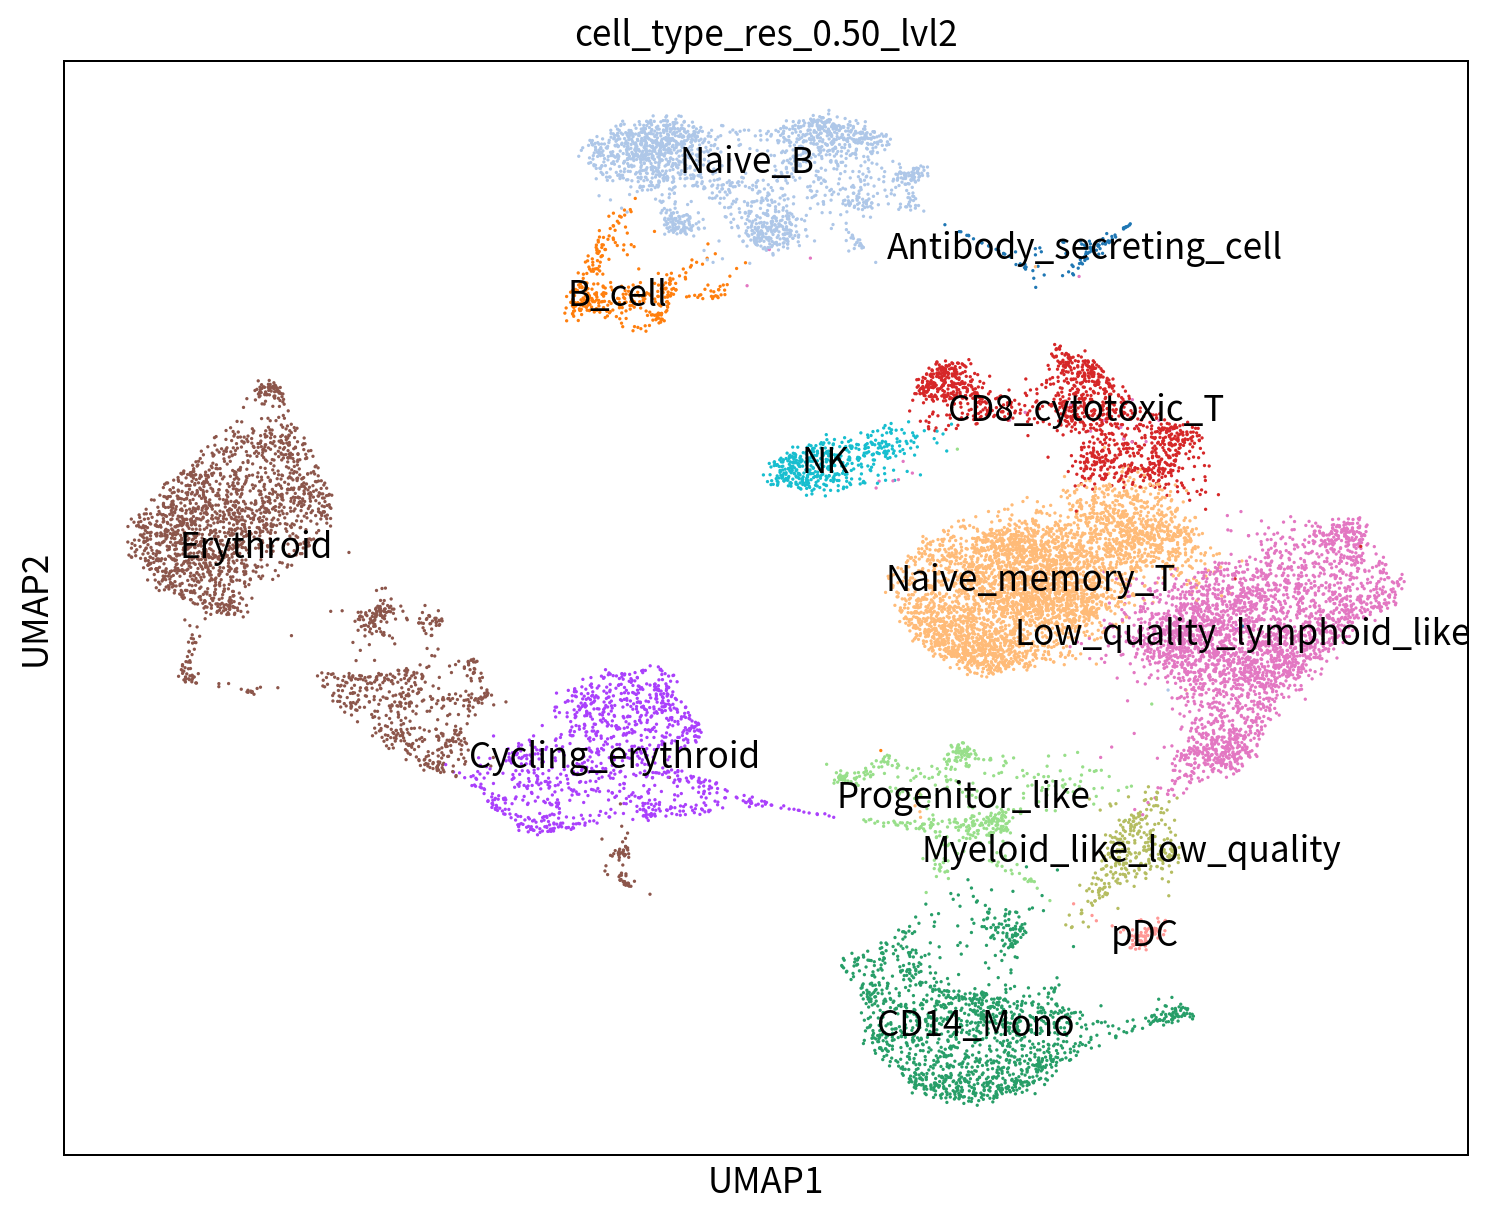

In [12]:
# 功能说明：单独绘制二级注释的 UMAP 图。
# 运行目的：清晰展示最终的细分细胞类型注释结果。
# 详细代码解析：
# 1. `with rc_context({"figure.figsize": (10, 8)}):`
#    - 临时设置图形大小为 10x8 英寸。
# 2. `sc.pl.umap(...)`
#    - `color=["cell_type_res_0.50_lvl2"]`: 仅展示二级注释。

# 查看注释结果
with rc_context({"figure.figsize": (10, 8)}):
    
    sc.pl.umap(
            adata,
            color=["cell_type_res_0.50_lvl2" ],
            legend_loc="on data",
            save="_08_210.pdf",
            )

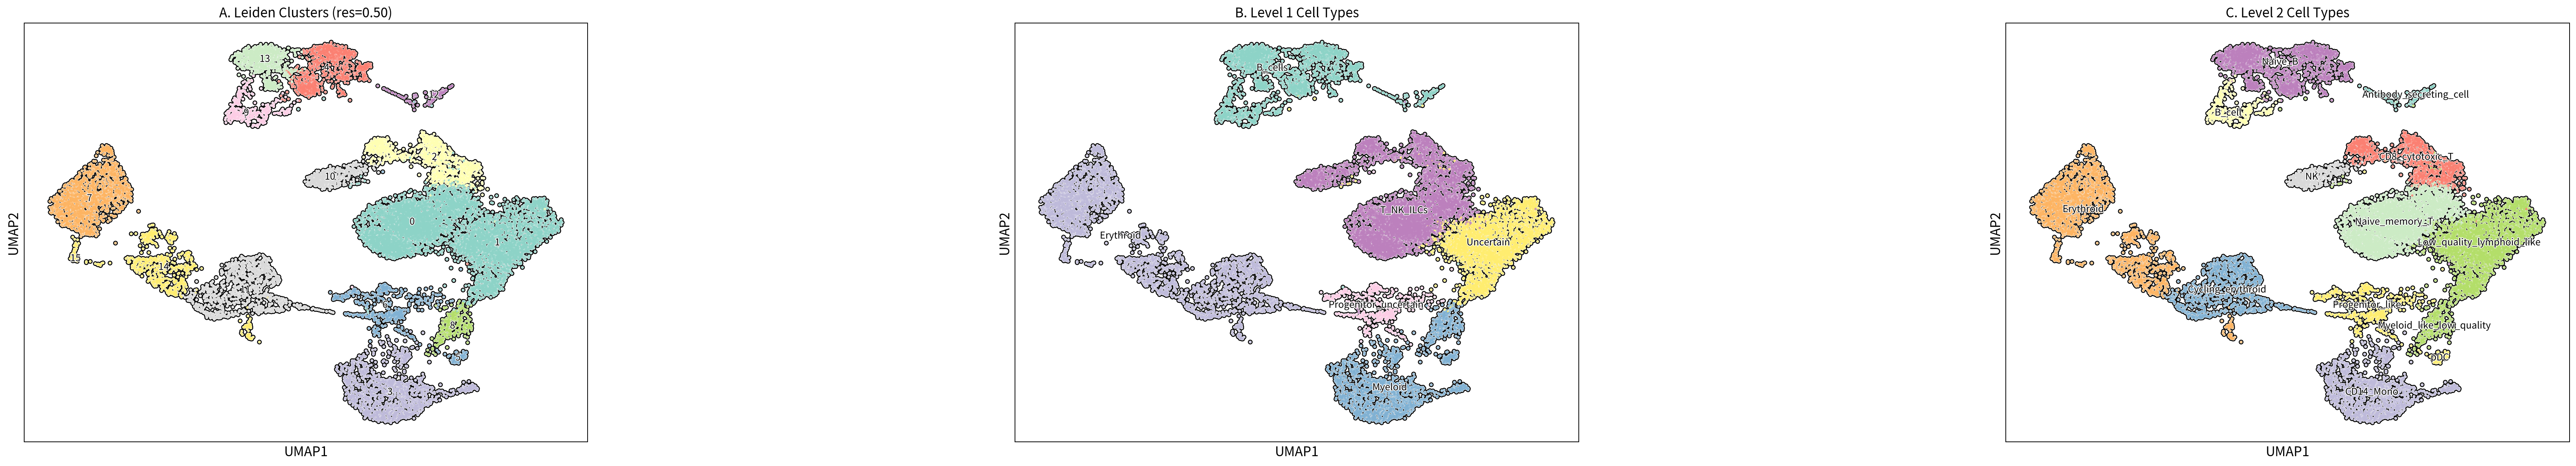

In [13]:
# 功能说明：绘制精美的多面板 UMAP 图，用于出版或展示。
# 运行目的：生成高质量的注释概览图，包含聚类、一级和二级注释，并进行详细的样式调整。
# 详细代码解析：
# 1. `with rc_context(...)`: 设置绘图上下文。
# 2. `sc.pl.umap(...)`:
#    - `color=[...]`: 展示三个层级的信息。
#    - `legend_loc`, `legend_fontsize`, `legend_fontoutline`: 优化图例显示。
#    - `size`, `add_outline`, `outline_width`, `outline_color`: 优化数据点样式，增加轮廓以提高区分度。
#    - `ncols`, `wspace`: 调整子图布局。
#    - `vmax`, `palette`: 调整颜色映射。
#    - `title`: 添加自定义标题。

with rc_context({"figure.figsize": (10, 8)}):
    sc.pl.umap(
        # 1. 数据对象
        adata,  # AnnData对象，包含单细胞数据和UMAP坐标
        
        # 2. 可视化内容：三个子图分别展示不同信息
        color=[
            leiden_res,              # 子图1: 分辨率0.50的Leiden聚类结果
            "cell_type_res_0.50_lvl1",      # 子图2: 一级细胞类型注释（基于分辨率0.50）
            "cell_type_res_0.50_lvl2",      # 子图3: 二级细胞类型注释（更细粒度的分类）
        ],
        # 3. 图例设置
        legend_loc="on data",               # 图例直接标注在数据点上，更直观
        legend_fontsize=10,                  # 减小字体大小以避免重叠（
     #   legend_fontweight='normal',         # 使用正常字体粗细，避免粗体占用过多空间
        legend_fontoutline=1.5,             # 添加1.5像素的字体描边，提高文字在复杂背景中的可读性
        # 4. 数据点设置
        size=25,                            # 数据点大小：平衡可视性和重叠问题（折中值）
        add_outline=True,                   # 为数据点添加轮廓，增强区分度
        outline_width=(0.4, 0.1),           # 轮廓宽度：外层0.4，内层0.1（更精细）
        outline_color=('black', 'white'),   # 轮廓颜色：外层黑色，内层白色，形成对比
        # 5. 子图布局
        ncols=3,                            # 3列布局（3个子图并排显示）
        wspace=0.6,                         # 子图之间的水平间距（0.6比0.5稍大，避免拥挤）
        
        # 6. 颜色映射设置
        vmax="p99",                         # 设置颜色映射最大值为第99百分位数，作用：去除极端值影响，使颜色分布更均匀
        palette="Set3",                     # 使用Set3调色板（适用于分类数据），Set3提供12种鲜明且易于区分的颜色
        # 7. 其他优化参数
       # frameon=False,                      # 去除子图边框，使图像更简洁
        show=False,                         # 不立即显示，便于后续调整或保存
        # 8. 新增参数优化
        alpha=0.8,                          # 设置透明度为0.8，在重叠区域显示更好
        edgecolor='none',                   # 去除边缘颜色，避免与轮廓冲突
        title=[                             # 为每个子图添加描述性标题
            "A. Leiden Clusters (res=0.50)", 
            "B. Level 1 Cell Types", 
            "C. Level 2 Cell Types"
        ],
     #  save="_08_211.pdf",
    )
ctx.capture("manual_annotation_overview")


In [14]:
# 功能说明：统计二级注释的细胞数量。
# 运行目的：查看各细分细胞类型的分布情况。
# 详细代码解析：
# 1. `adata.obs["cell_type_res_0.50_lvl2"].value_counts()`
#    - 统计二级注释列中各类别的频数。

# 查看每个类群细胞数量
adata.obs["cell_type_res_0.50_lvl2"].value_counts()

cell_type_res_0.50_lvl2
Naive_memory_T               3946
Low_quality_lymphoid_like    3101
Erythroid                    2445
Naive_B                      1891
CD14_Mono                    1511
CD8_cytotoxic_T              1260
Cycling_erythroid            1057
Progenitor_like               502
NK                            458
B_cell                        382
Myeloid_like_low_quality      298
Antibody_secreting_cell       106
pDC                            84
Name: count, dtype: int64

## 保存本章结果

保存表格、参数摘要和可供后续章节读取的数据。

In [15]:
keys = ["cell_type_res_0.02_lvl1", "cell_type_res_0.50_lvl1", "cell_type_res_0.50_lvl2"]
ctx.table("manual_annotations", adata.obs[keys + ["samples", "leiden_res_0_02", "leiden_res_0_50"]])
for key in keys:
    ctx.table(key.replace(".", "_") + "_by_sample", pd.crosstab(adata.obs[key], adata.obs["samples"]))
ctx.finish(adata, {"fine_cell_types": adata.obs[keys[-1]].value_counts().to_dict()})

本章计算完成。请阅读本次图表和表格，再更新本章解读。


## 结果阅读与思考

请打开本次结果目录中的 summary.json、tables 和 figures。将目的、方法、结果和解释写入本章报告源稿，再更新 Word。

思考题：为什么更换聚类参数后不能照搬以前的编号映射？

运行与报告操作见课程根目录的 99_运行与AI协作指南.md。